# LangGraph Subgraphs — Different State Schemas

This notebook demonstrates the **different-schema** pattern for LangGraph
subgraphs: the subgraph (`SubState`) has its own state shape, separate from
the parent graph's (`ParentState`). Because the schemas differ, the parent
graph can't add the compiled subgraph directly as a node — instead a small
wrapper node (`translate_answer`) calls `subgraph.invoke(...)`, translating
between the two state shapes by hand.

Flow: `question` → generate an English answer (parent) → invoke the subgraph
to translate it to Hindi (subgraph has its own `input_text`/`translated_text`
state).

**Models (local, via [Ollama](https://ollama.com), no API key required):**
- `llama3.2:3b` — small, fast local model used to generate the initial English answer.
- `gpt-oss:120b-cloud` — larger model (run through Ollama's cloud inference) used for the Hindi translation, where quality matters more.

**Prerequisites:**
1. [Ollama](https://ollama.com) installed and running.
2. Models pulled/available: `ollama pull llama3.2:3b` and `ollama pull gpt-oss:120b-cloud` (the `-cloud` model needs `ollama signin` once, since it runs on Ollama's cloud rather than your machine).
3. Run this notebook using the project's `.venv` kernel (it already has `langchain-ollama`, `langgraph`, etc. installed).

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [2]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

**Subgraph's own state** — deliberately different from `ParentState` (below):
it only knows about `input_text` / `translated_text`, not `question` or
`answer_eng`.

In [3]:
subgraph_llm = ChatOllama(model='gpt-oss:120b-cloud')

The subgraph uses the bigger `gpt-oss:120b-cloud` model, since translation
quality benefits from a larger model.

In [4]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

**Subgraph node** — translates `input_text` into `translated_text`.

In [5]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

**Build & compile the subgraph** on its own `SubState` — a single
`translate_text` node from `START` to `END`.

In [6]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

**Parent state** — separate schema from the subgraph's `SubState`, which is
exactly why the parent graph will need a wrapper node to bridge between them.

In [13]:
#parent_llm = ChatOllama(model='llama3.2:3b')
parent_llm = ChatOllama(model='gpt-oss:120b-cloud')

The parent graph uses the small, fast `llama3.2:3b` model to draft the
English answer.

In [14]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

**Parent node** — generates the English answer for the incoming `question`.

In [15]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

**Wrapper node** — this is the bridge between the two schemas: it builds the
subgraph's `SubState` input from `ParentState`, invokes the subgraph, then
maps the subgraph's output back into `ParentState`.

In [16]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

**Build the parent graph.** Unlike the shared-schema notebook, `translate` here
is the plain Python wrapper function (`translate_answer`), not the compiled
subgraph itself.

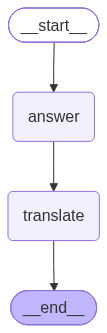

In [17]:
graph = parent_builder.compile()

graph

Compile the parent graph and (in a notebook with Mermaid/graphviz support)
render it.

In [18]:
graph.invoke({'question': 'Why Katappa kills Bahubali?'})

{'question': 'Why Katappa kills Bahubali?',
 'answer_eng': '**Spoiler warning – the answer contains major plot points from *Baahubali: The Beginning* and *Baahubali: The Conclusion*.**  \n\nIn the *Baahubali* saga, Kattappa (often spelled “Katappa”) is a **devout, lifelong servant of the throne of Mahishmati**, bound by an oath that obliges him to obey the reigning monarch no matter what. This oath is the central reason why he ends up killing Amarendra\u202fBaahubali, even though he loves and respects the hero.\n\n### The chain of events that lead to Kattappa’s act\n\n| Step | What happens | Why it matters to Kattappa |\n|------|--------------|----------------------------|\n| 1. **Baahulali’s rise** | Amarendra\u202fBaahubali becomes the beloved prince and later the king of Mahishmati, winning the love of the people, the royal family, and Kattappa himself. | Kattappa sees Baahubali as a worthy ruler and a friend. |\n| 2. **Political intrigue** | Bhallaladeva, Baahubali’s cousin, and hi

Run the whole graph end-to-end: ask a question in English, get back both the
English answer and its Hindi translation.